### Comparison of Author Grouping Strategies

In [9]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# load cosine_similarities_fullname
pickle_filename = "./Full-Name Matching/cosine_similarities_fullname.pkl"
with open(pickle_filename, 'rb') as f:
    cosine_similarities_fullname = pickle.load(f)

# load cosine_similarities_surname
pickle_filename = "./Surname Matching/cosine_similarities_surname.pkl"
with open(pickle_filename, 'rb') as f:
    cosine_similarities_surname = pickle.load(f)

# load cosine_similarities_normalized_indel_distance
pickle_filename = "./Normalized Indel Distance Matching/cosine_similarities_normalized_indel_distance.pkl"
with open(pickle_filename, 'rb') as f:
    cosine_similarities_normalized_indel_distance = pickle.load(f)

In [17]:
# create Series and count the number of DataFrames with zero papers 
for i, cpl_list in enumerate([cosine_similarities_fullname, cosine_similarities_surname, cosine_similarities_normalized_indel_distance]):
    means_cpl_sr = pd.Series([df.shape[0] for df in cpl_list])
    num_zero_authors = (means_cpl_sr == 0).sum()
    print(f'Number of DataFrames with zero authors: {num_zero_authors}')

Number of DataFrames with zero authors: 16
Number of DataFrames with zero authors: 10
Number of DataFrames with zero authors: 12


In [11]:
# create Series and print descriptive statistics for each list
for i, cpl_list in enumerate([cosine_similarities_fullname, cosine_similarities_surname, cosine_similarities_normalized_indel_distance]):
    means_cpl_sr = pd.Series([df.shape[0] for df in cpl_list])
    print(f"\nDescriptive statistics for cosine_similarities{['_fullname', '_suranme', '_normalized_indel_distance'][i]}:")
    print(means_cpl_sr.describe())
    print()


Descriptive statistics for cosine_similarities_fullname:
count    30659.00000
mean         4.64751
std          5.92753
min          0.00000
25%          2.00000
50%          3.00000
75%          5.00000
max        181.00000
dtype: float64


Descriptive statistics for cosine_similarities_suranme:
count    20582.000000
mean         8.211058
std         26.799456
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max       1587.000000
dtype: float64


Descriptive statistics for cosine_similarities_normalized_indel_distance:
count    24390.000000
mean         6.545264
std          9.130301
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        214.000000
dtype: float64



In [18]:
# define a function to process each dataframe and calculate mean_author_cos_sim
def calculate_mean_author_cos_sim(cosine_similarities):
    cosine_similarities_filtered = [a for a in cosine_similarities if len(a) > 1]
    mean_author_cos_sim = [(np.sum(a.values)-len(a))/2 / ((len(a)-1)*len(a)/2) for a in cosine_similarities_filtered]
    return pd.Series(mean_author_cos_sim)

# calculate mean_author_cos_sim for each dataframe
mean_author_cos_sim_series_fullname = calculate_mean_author_cos_sim(cosine_similarities_fullname)
mean_author_cos_sim_series_surname = calculate_mean_author_cos_sim(cosine_similarities_surname)
mean_author_cos_sim_series_normalized_indel_distance = calculate_mean_author_cos_sim(cosine_similarities_normalized_indel_distance)

# print mean_author_cos_sim for each dataframe
mean_value_fullname = mean_author_cos_sim_series_fullname.describe().loc['mean']
print(f"Mean Author Cosine Similarity Full-Name: {mean_value_fullname * 100:.2f}%")

mean_value_surname = mean_author_cos_sim_series_surname.describe().loc['mean']
print(f"Mean Author Cosine Similarity Surname: {mean_value_surname * 100:.2f}%")

mean_value_normalized_indel_distance = mean_author_cos_sim_series_normalized_indel_distance.describe().loc['mean']
print(f"Mean Author Cosine Similarity Normalized Indel Distance: {mean_value_normalized_indel_distance * 100:.2f}%")

Mean Author Cosine Similarity Full-Name: 15.57%
Mean Author Cosine Similarity Surname: 11.60%
Mean Author Cosine Similarity Normalized Indel Distance: 14.04%


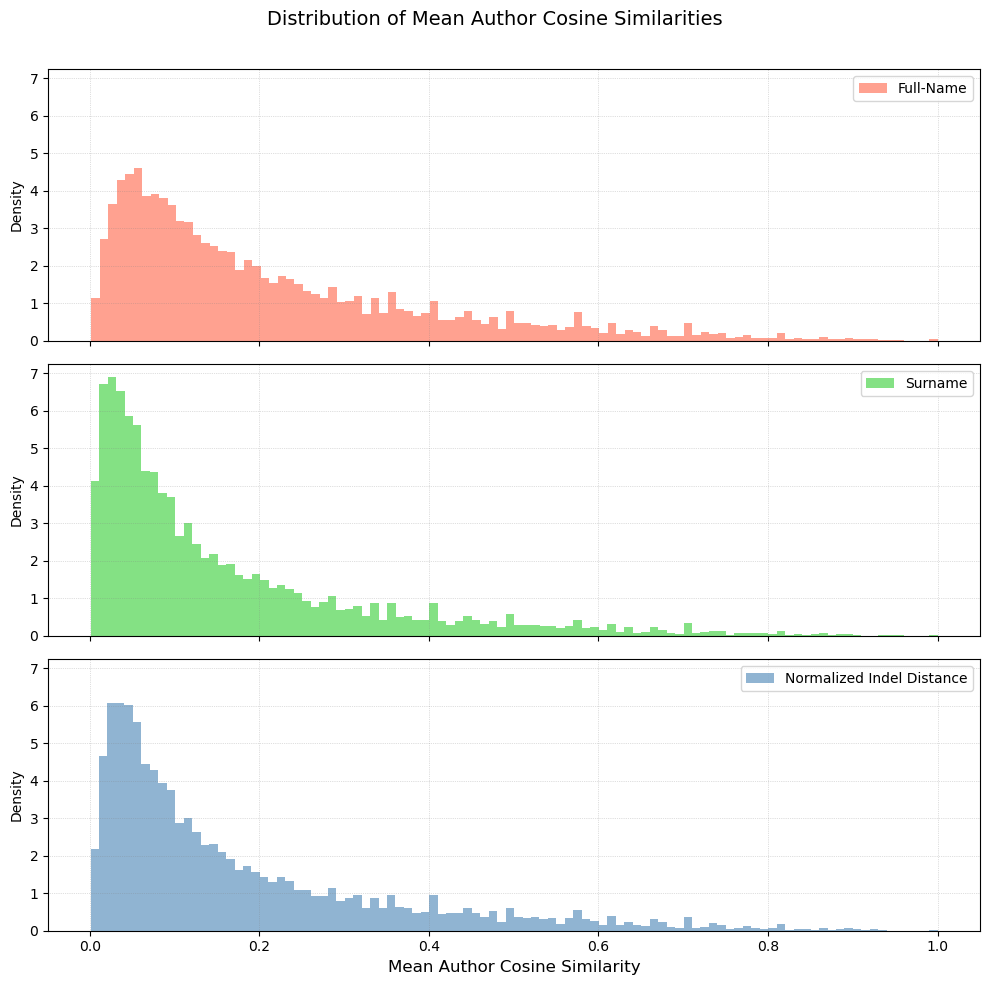

In [22]:
# plot the histograms
fig, axs = plt.subplots(figsize=(10, 10), nrows=3, sharey=True, sharex=True)

# define a color palette
color_palette = ["#FF6347", "#32CD32", "#4682B4"]

# histogram for full-name
mean_author_cos_sim_series_fullname[mean_author_cos_sim_series_fullname > 0].hist(
    bins=100, alpha=0.6, label='Full-Name', density=True, color=color_palette[0], ax=axs[0])
axs[0].legend(loc='upper right')

# histogram for surname
mean_author_cos_sim_series_surname[mean_author_cos_sim_series_surname > 0].hist(
    bins=100, alpha=0.6, label='Surname', density=True, color=color_palette[1], ax=axs[1])
axs[1].legend(loc='upper right')

# histogram for normalized indel distance
mean_author_cos_sim_series_normalized_indel_distance[mean_author_cos_sim_series_normalized_indel_distance > 0].hist(
    bins=100, alpha=0.6, label='Normalized Indel Distance', density=True, color=color_palette[2], ax=axs[2])
axs[2].legend(loc='upper right')

# add labels and title
for ax in axs:
    ax.set_ylabel("Density")
    ax.grid(True, which="both", linestyle=':', linewidth=0.5, color='grey', alpha=0.5)

plt.xlabel('Mean Author Cosine Similarity', fontsize=12)
fig.suptitle('Distribution of Mean Author Cosine Similarities', fontsize=14)

# show plot
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()